Training XGBoost...

--- XGBoost Results ---
XGBoost Challenge Score (Top 5% TPR): 0.063
XGBoost AUC: 0.807


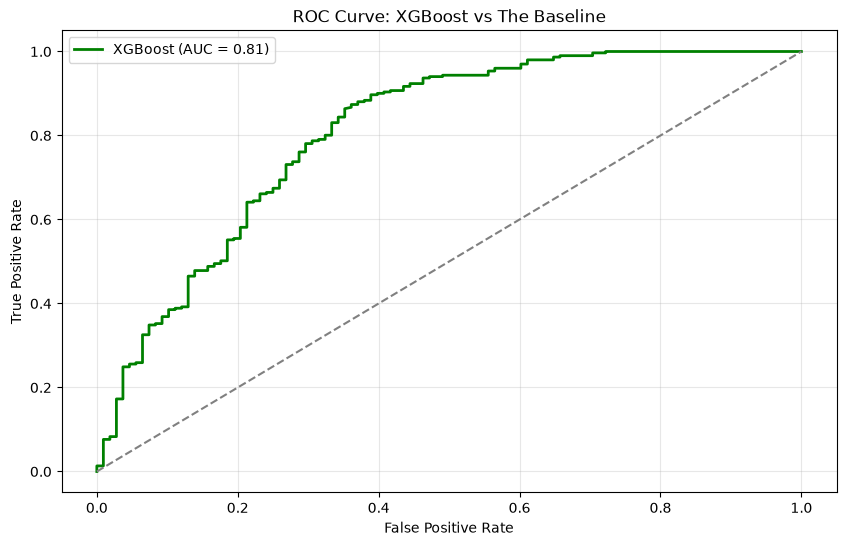

In [2]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. Load the exact same data
df = pd.read_csv('ecg_features_expanded.csv')
X = df[['Age', 'Sex', 'Mean_RR_ms', 'SDNN_ms', 'QRS_Duration_ms']]
y = df['Label']
groups = df['Patient_ID']

# 2. Split the data (preventing patient leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 3. Train the "Smart" XGBoost Model
print("Training XGBoost...")
# We use standard hyperparameters that usually perform very well out of the box
xgb_model = xgb.XGBClassifier(
    n_estimators=200,        # Number of sequential "doctors"
    learning_rate=0.05,      # How aggressively they correct mistakes
    max_depth=4,             # How complex each rule can be
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 4. Get Predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# 5. Challenge Score Metric
def calculate_challenge_score(y_true, y_pred_proba):
    results = pd.DataFrame({'True_Label': y_true, 'Risk_Score': y_pred_proba})
    results = results.sort_values(by='Risk_Score', ascending=False)
    top_5_percent_count = max(1, int(len(results) * 0.05))
    top_5_patients = results.head(top_5_percent_count)
    true_positives_in_top = top_5_patients['True_Label'].sum()
    total_true_positives = results['True_Label'].sum()
    return true_positives_in_top / total_true_positives if total_true_positives > 0 else 0

xgb_challenge_score = calculate_challenge_score(y_test, xgb_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("\n--- XGBoost Results ---")
print(f"XGBoost Challenge Score (Top 5% TPR): {xgb_challenge_score:.3f}")
print(f"XGBoost AUC: {xgb_auc:.3f}")

# 6. Plot the ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.2f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve: XGBoost vs The Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training LightGBM...

--- LightGBM Results ---
LightGBM AUC: 0.804


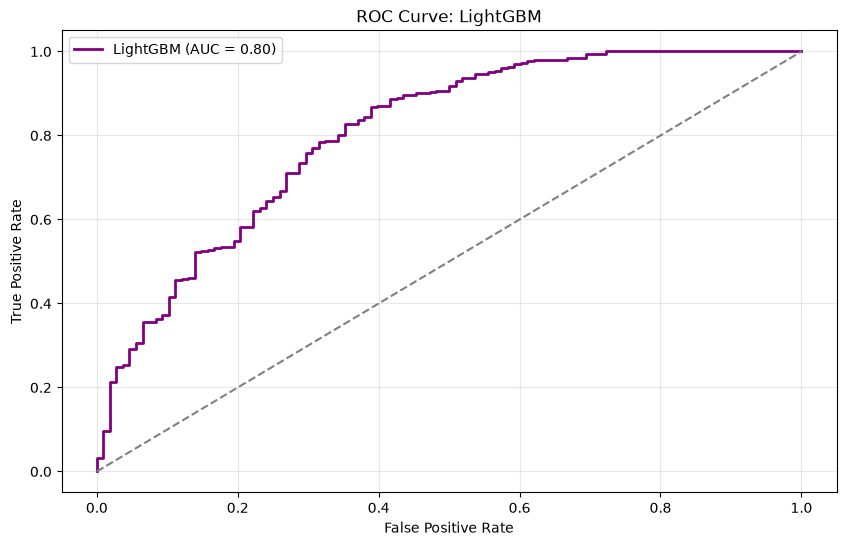

In [1]:
import lightgbm as lgb
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Load and Split Data (identical setup for a fair comparison)
df = pd.read_csv('ecg_features_expanded.csv')
X = df[['Age', 'Sex', 'Mean_RR_ms', 'SDNN_ms', 'QRS_Duration_ms']]
y = df['Label']
groups = df['Patient_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 2. Train LightGBM
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

# 3. Get Predictions & AUC Score
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_probs)

print(f"\n--- LightGBM Results ---")
print(f"LightGBM AUC: {lgb_auc:.3f}")

# 4. Plot the ROC Curve
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_probs)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgb_auc:.2f})', color='purple', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve: LightGBM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()